# IPL Data Analysis

## Importing Required Libraries

Pandas is used for data manipulation and analysis, while NumPy is used for numerical operations.

In [2]:
import pandas as pd
import numpy as np

## Loading Datasets

Two datasets are used:

1. **matches.csv** : Contains match-level information.
2. **deliveries.csv** : Contains ball-by-ball information.

In [ ]:
matches = pd.read_csv("matches.csv.xls")
deliveries = pd.read_csv("deliveries.csv.xls")

## Dataset Dimensions

The matches dataset contains information about IPL matches, while the deliveries dataset stores ball-by-ball records.

In [4]:
print("Matches Shape :", matches.shape)
print("Deliveries Shape :", deliveries.shape)

Matches Shape : (1095, 20)
Deliveries Shape : (260920, 17)


## Preview of Datasets

The first five rows are displayed to understand the structure and columns available in both datasets.

In [5]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [6]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


## Dataset Information

The `.info()` function provides:

- Number of rows and columns
- Data types of columns
- Missing values

In [7]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [8]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

## Missing Value Analysis

Some columns contain missing values. These missing values need to be handled before performing analysis.

In [9]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [10]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

## Duplicate Records

Duplicate rows are checked to avoid repeated information affecting the analysis.

In [11]:
print("Duplicate rows in matches:", matches.duplicated().sum())

print("Duplicate rows in deliveries:", deliveries.duplicated().sum())

Duplicate rows in matches: 0
Duplicate rows in deliveries: 0


## Data Types

Understanding data types is important because numerical and categorical columns require different kinds of analysis.

In [12]:
matches.dtypes

id                   int64
season              object
city                object
date                object
match_type          object
player_of_match     object
venue               object
team1               object
team2               object
toss_winner         object
toss_decision       object
winner              object
result              object
result_margin      float64
target_runs        float64
target_overs       float64
super_over          object
method              object
umpire1             object
umpire2             object
dtype: object

In [13]:
deliveries.dtypes

match_id             int64
inning               int64
batting_team        object
bowling_team        object
over                 int64
ball                 int64
batter              object
bowler              object
non_striker         object
batsman_runs         int64
extra_runs           int64
total_runs           int64
extras_type         object
is_wicket            int64
player_dismissed    object
dismissal_kind      object
fielder             object
dtype: object

In [14]:
matches['date'] = pd.to_datetime(matches['date'])

In [15]:
matches['date'].dtype

dtype('<M8[ns]')

## Date Conversion

The date column is converted into datetime format to enable year-wise and season-wise analysis.

## Standardize Team Names

In [16]:
matches['team1'].unique().tolist()

['Royal Challengers Bangalore',
 'Kings XI Punjab',
 'Delhi Daredevils',
 'Mumbai Indians',
 'Kolkata Knight Riders',
 'Rajasthan Royals',
 'Deccan Chargers',
 'Chennai Super Kings',
 'Kochi Tuskers Kerala',
 'Pune Warriors',
 'Sunrisers Hyderabad',
 'Gujarat Lions',
 'Rising Pune Supergiants',
 'Rising Pune Supergiant',
 'Delhi Capitals',
 'Punjab Kings',
 'Lucknow Super Giants',
 'Gujarat Titans',
 'Royal Challengers Bengaluru']

In [17]:
team_mapping = {
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Kings XI Punjab': 'Punjab Kings',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}

# For matches dataset
matches.replace(team_mapping, inplace=True)

# For deliveries dataset (if applicable)
deliveries.replace(team_mapping, inplace=True)

In [18]:
sorted(matches['team1'].unique())

['Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Gujarat Lions',
 'Gujarat Titans',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Lucknow Super Giants',
 'Mumbai Indians',
 'Pune Warriors',
 'Punjab Kings',
 'Rajasthan Royals',
 'Rising Pune Supergiants',
 'Royal Challengers Bengaluru',
 'Sunrisers Hyderabad']

## Team Name Standardization

Several IPL franchises have undergone name changes over different seasons. To maintain consistency and avoid treating the same franchise as separate teams, team names were standardized.

The following replacements were performed:

- Royal Challengers Bangalore → Royal Challengers Bengaluru
- Kings XI Punjab → Punjab Kings
- Delhi Daredevils → Delhi Capitals
- Rising Pune Supergiant → Rising Pune Supergiants

This ensures accurate team-wise analysis and prevents duplication caused by historical naming variations.

## checking unique venues

In [19]:
matches['venue'].nunique()

58

In [20]:
matches['venue'].unique()

array(['M Chinnaswamy Stadium',
       'Punjab Cricket Association Stadium, Mohali', 'Feroz Shah Kotla',
       'Wankhede Stadium', 'Eden Gardens', 'Sawai Mansingh Stadium',
       'Rajiv Gandhi International Stadium, Uppal',
       'MA Chidambaram Stadium, Chepauk', 'Dr DY Patil Sports Academy',
       'Newlands', "St George's Park", 'Kingsmead', 'SuperSport Park',
       'Buffalo Park', 'New Wanderers Stadium', 'De Beers Diamond Oval',
       'OUTsurance Oval', 'Brabourne Stadium',
       'Sardar Patel Stadium, Motera', 'Barabati Stadium',
       'Brabourne Stadium, Mumbai',
       'Vidarbha Cricket Association Stadium, Jamtha',
       'Himachal Pradesh Cricket Association Stadium', 'Nehru Stadium',
       'Holkar Cricket Stadium',
       'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
       'Subrata Roy Sahara Stadium',
       'Maharashtra Cricket Association Stadium',
       'Shaheed Veer Narayan Singh International Stadium',
       'JSCA International Stadium Complex', 'Sh

In [21]:
venue_mapping = {
    'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
    'M Chinnaswamy Stadium, Bengaluru': 'M Chinnaswamy Stadium',

    'Punjab Cricket Association Stadium, Mohali': 'Punjab Cricket Association IS Bindra Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali': 'Punjab Cricket Association IS Bindra Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh': 'Punjab Cricket Association IS Bindra Stadium',

    'MA Chidambaram Stadium, Chepauk': 'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai': 'MA Chidambaram Stadium',

    'Wankhede Stadium, Mumbai': 'Wankhede Stadium',

    'Brabourne Stadium, Mumbai': 'Brabourne Stadium',

    'Arun Jaitley Stadium, Delhi': 'Arun Jaitley Stadium',
    'Feroz Shah Kotla': 'Arun Jaitley Stadium',

    'Rajiv Gandhi International Stadium, Uppal, Hyderabad': 'Rajiv Gandhi International Stadium',
    'Rajiv Gandhi International Stadium, Uppal': 'Rajiv Gandhi International Stadium',

    'Dr DY Patil Sports Academy, Mumbai': 'Dr DY Patil Sports Academy',

    'Maharashtra Cricket Association Stadium, Pune': 'Maharashtra Cricket Association Stadium',

    'Eden Gardens, Kolkata': 'Eden Gardens',

    'Sawai Mansingh Stadium, Jaipur': 'Sawai Mansingh Stadium',

    'Himachal Pradesh Cricket Association Stadium, Dharamsala':
        'Himachal Pradesh Cricket Association Stadium',

    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam':
        'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium'
}

matches['venue'] = matches['venue'].replace(venue_mapping)

In [22]:
print("Number of unique venues:", matches['venue'].nunique())
sorted(matches['venue'].unique())

Number of unique venues: 39


['Arun Jaitley Stadium',
 'Barabati Stadium',
 'Barsapara Cricket Stadium, Guwahati',
 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow',
 'Brabourne Stadium',
 'Buffalo Park',
 'De Beers Diamond Oval',
 'Dr DY Patil Sports Academy',
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
 'Dubai International Cricket Stadium',
 'Eden Gardens',
 'Green Park',
 'Himachal Pradesh Cricket Association Stadium',
 'Holkar Cricket Stadium',
 'JSCA International Stadium Complex',
 'Kingsmead',
 'M Chinnaswamy Stadium',
 'MA Chidambaram Stadium',
 'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur',
 'Maharashtra Cricket Association Stadium',
 'Narendra Modi Stadium, Ahmedabad',
 'Nehru Stadium',
 'New Wanderers Stadium',
 'Newlands',
 'OUTsurance Oval',
 'Punjab Cricket Association IS Bindra Stadium',
 'Rajiv Gandhi International Stadium',
 'Sardar Patel Stadium, Motera',
 'Saurashtra Cricket Association Stadium',
 'Sawai Mansingh Stadium',
 'Shaheed Veer

## Venue Name Standardization

Several venues appeared with multiple names due to changes in naming conventions or inclusion of city names. These inconsistencies were removed by standardizing venue names.

Examples:

- Feroz Shah Kotla → Arun Jaitley Stadium
- M.Chinnaswamy Stadium → M Chinnaswamy Stadium
- MA Chidambaram Stadium, Chepauk → MA Chidambaram Stadium
- Wankhede Stadium, Mumbai → Wankhede Stadium
- Eden Gardens, Kolkata → Eden Gardens

Standardizing venue names ensures accurate venue-wise analysis and prevents duplicate representation of the same stadium.

In [23]:
print("Unique match IDs in matches dataset :", matches['id'].nunique())

print("Unique match IDs in deliveries dataset :", deliveries['match_id'].nunique())

Unique match IDs in matches dataset : 1095
Unique match IDs in deliveries dataset : 1095


In [24]:
set(matches['id']) - set(deliveries['match_id'])

set()

In [25]:
set(deliveries['match_id']) - set(matches['id'])

set()

## Match ID Consistency Check

The match identifiers from both datasets were compared to ensure consistency.

### Findings

- The matches dataset contains 1095 unique match IDs.
- The deliveries dataset also contains 1095 unique match IDs.
- No mismatches were found between the two datasets.

### Conclusion

The ball-by-ball data perfectly corresponds to the match-level data. Therefore, the datasets are fully consistent and can be merged without any loss of information.

In [26]:
sorted(matches['season'].unique())

['2007/08',
 '2009',
 '2009/10',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020/21',
 '2021',
 '2022',
 '2023',
 '2024']

In [27]:
matches['season_year'] = matches['season'].str[:4].astype(int)

In [28]:
sorted(matches['season_year'].unique())

[2007,
 2009,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024]

## Seasons Available

The dataset contains IPL matches spanning from 2007/08 to 2024.

### Findings

- A total of 16 IPL seasons are present.
- Some seasons are represented using combined years (e.g., 2007/08, 2009/10, and 2020/21).
- The dataset covers the complete evolution of the IPL across multiple years.

### Conclusion

The availability of multiple seasons enables year-wise and season-wise analysis of teams, players, venues, and match outcomes.

## Team Consistency

In [29]:
sorted(matches['team1'].unique())

['Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Gujarat Lions',
 'Gujarat Titans',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Lucknow Super Giants',
 'Mumbai Indians',
 'Pune Warriors',
 'Punjab Kings',
 'Rajasthan Royals',
 'Rising Pune Supergiants',
 'Royal Challengers Bengaluru',
 'Sunrisers Hyderabad']

In [30]:
len(matches['team1'].unique())

15

## Team Consistency Check

The team names were examined and standardized to account for franchise name changes over different IPL seasons.

### Findings

- A total of 15 unique franchises are present in the dataset.
- Historical team names were standardized to maintain consistency.
- Defunct franchises such as Deccan Chargers, Kochi Tuskers Kerala, Gujarat Lions, and Pune Warriors were retained as separate entities since they represent different teams.

### Conclusion

The team names are consistent and suitable for team-wise analysis. Standardization prevents duplicate representation of the same franchise and improves the accuracy of statistical analysis.

In [31]:
ipl = deliveries.merge(
    matches,
    left_on='match_id',
    right_on='id',
    how='inner'
)

ipl.shape

(260920, 38)

## Dataset Integration

The ball-by-ball dataset was merged with the match-level dataset using the match identifier. This created a comprehensive dataset containing both delivery-level and match-level information, enabling detailed analysis of players, teams, venues, and match outcomes.

#  Question 1: Load & Merge the Datasets

In [32]:
ipl = deliveries.merge(
    matches,
    left_on='match_id',
    right_on='id',
    how='inner'
)

ipl.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,season_year
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,2007
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,2007
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,2007
3,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,2007
4,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,2007


In [33]:
print("Matches Shape:", matches.shape)
print("Deliveries Shape:", deliveries.shape)
print("Merged Dataset Shape:", ipl.shape)

Matches Shape: (1095, 21)
Deliveries Shape: (260920, 17)
Merged Dataset Shape: (260920, 38)


In [34]:
print("Columns in merged dataset:\n")
print(ipl.columns.tolist())

Columns in merged dataset:

['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder', 'id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2', 'season_year']


In [35]:
ipl.dtypes

match_id                     int64
inning                       int64
batting_team                object
bowling_team                object
over                         int64
ball                         int64
batter                      object
bowler                      object
non_striker                 object
batsman_runs                 int64
extra_runs                   int64
total_runs                   int64
extras_type                 object
is_wicket                    int64
player_dismissed            object
dismissal_kind              object
fielder                     object
id                           int64
season                      object
city                        object
date                datetime64[ns]
match_type                  object
player_of_match             object
venue                       object
team1                       object
team2                       object
toss_winner                 object
toss_decision               object
winner              

In [36]:
print("Seasons Covered:")
print(sorted(matches['season'].unique()))

print("\nTotal Seasons:", matches['season'].nunique())

Seasons Covered:
['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']

Total Seasons: 17


## Conclusion

The match-level and ball-by-ball datasets were successfully integrated into a single analytical dataset. The resulting dataset provides detailed information across 16 IPL seasons and is suitable for performing player, team, venue, and match-related analyses.

# Question 2

In [37]:
# Missing values in matches dataset
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
season_year           0
dtype: int64

In [38]:
# Missing values in deliveries dataset
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [39]:
matches['city'].isnull().sum()

51

## Option Chosen: Imputation

Since city information can often be inferred from the venue, it is preferable to impute rather than drop rows. Dropping rows would lead to the loss of valuable match records.

In [40]:
# Fill missing cities using venue information
matches.loc[matches['venue'] == 'Dubai International Cricket Stadium', 'city'] = 'Dubai'
matches.loc[matches['venue'] == 'Sharjah Cricket Stadium', 'city'] = 'Sharjah'
matches.loc[matches['venue'] == 'Sheikh Zayed Stadium', 'city'] = 'Abu Dhabi'

# Check remaining missing values
matches['city'].isnull().sum()

0

##  Handling Missing Values in City

Some records contained missing values in the `city` column.

Instead of dropping these matches, missing city values were imputed based on the corresponding venue. This approach preserves all match records and maintains the completeness of the dataset.

In [41]:
matches['player_of_match'].isnull().sum()

5

In [42]:
matches['player_of_match'] = matches['player_of_match'].fillna('No Award')



#Missing values in player_of_match do not affect other match information. 
#Therefore, replacing them with 'No Award' preserves all records without losing information.

In [43]:
matches['player_of_match'].isnull().sum()   #verify


0

In [44]:
deliveries['dismissal_kind'].isnull().sum()

247970

In [45]:
deliveries['dismissal_kind'] = deliveries['dismissal_kind'].fillna('not out')

In [46]:
deliveries['dismissal_kind'].isnull().sum()

0

## Handling Missing Values in Dismissal Type

Most deliveries do not result in a wicket, leading to missing values in the `dismissal_kind` column.

These missing values were replaced with "not out" to explicitly indicate that no dismissal occurred on those deliveries.

## Conclusion

Appropriate techniques were used to handle missing values while preserving the integrity of the datasets. Imputation and replacement strategies were preferred over deletion to avoid unnecessary loss of match and delivery information, resulting in a more complete and reliable dataset for analysis.

# Question 3

In [47]:
# Create total_runs
ipl['total_runs'] = ipl['batsman_runs'] + ipl['extra_runs']

In [48]:
ipl[['batsman_runs', 'extra_runs', 'total_runs']].head()

,batsman_runs,extra_runs,total_runs
0,0,1,1
1,0,0,0
2,0,1,1
3,0,0,0
4,0,0,0


## Creating Total Runs Feature

A new column named `total_runs` was created by adding batsman runs and extra runs.

This feature represents the actual runs scored on each delivery and is useful for innings, over, and match-level analysis.

In [49]:
#Create is_boundary Using NumPy
import numpy as np

ipl['is_boundary'] = np.where(
    ipl['batsman_runs'] >= 4,
    'boundary',
    'non-boundary'
)

In [50]:
ipl[['batsman_runs', 'is_boundary']].head()

,batsman_runs,is_boundary
0,0,non-boundary
1,0,non-boundary
2,0,non-boundary
3,0,non-boundary
4,0,non-boundary


## Boundary Classification

Using NumPy, deliveries were classified as either boundary or non-boundary.

Deliveries with batsman runs greater than or equal to four were labeled as "boundary", while the remaining deliveries were classified as "non-boundary".

In [51]:
#Create Over Phase
#First, inspect the over column


ipl['over'].head(10)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    1
8    1
9    1
Name: over, dtype: int64

In [52]:
ipl['over_number'] = ipl['over'] + 1

In [53]:
ipl[['over', 'over_number']].head(10)

,over,over_number
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
5,0,1
6,0,1
7,1,2
8,1,2
9,1,2


In [54]:
ipl['over_phase'] = np.where(
    ipl['over_number'] <= 6,
    'Powerplay',
    np.where(
        ipl['over_number'] <= 15,
        'Middle',
        'Death'
    )
)

In [55]:
ipl[['over_number', 'over_phase']].sample(10)

,over_number,over_phase
4554,7,Middle
149884,7,Middle
233783,2,Powerplay
23754,14,Middle
9747,11,Middle
245366,10,Middle
30322,16,Death
95199,8,Middle
97773,2,Powerplay
186927,19,Death


## Over Phase Classification

The over column in the dataset starts from 0, representing the first over. Therefore, a new column `over_number` was created by adding 1 to the original over values.

Based on the over number, deliveries were categorized into three phases:

- Powerplay (Overs 1–6)
- Middle Overs (Overs 7–15)
- Death Overs (Overs 16–20)

This classification enables phase-wise analysis of batting and bowling performance.

In [56]:
ipl['date'] = pd.to_datetime(ipl['date'])

In [57]:
ipl['date'].dtypes

dtype('<M8[ns]')

In [58]:
#Extract Year and Month from Date

In [59]:
ipl['year'] = ipl['date'].dt.year
ipl['month'] = ipl['date'].dt.month

In [60]:
ipl[['date', 'year', 'month']].head()

,date,year,month
0,2008-04-18,2008,4
1,2008-04-18,2008,4
2,2008-04-18,2008,4
3,2008-04-18,2008,4
4,2008-04-18,2008,4


## Observations

- A new column `total_runs` was created to represent the actual runs scored on each delivery.
- Deliveries were classified as boundary and non-boundary using NumPy.
- Overs were categorized into Powerplay, Middle, and Death phases.
- Year and month were extracted from the match date to support trend analysis.
- These engineered features provide additional insights into scoring patterns and match dynamics.

In [61]:
ipl[['over']].head(10)

,over
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,1
8,1
9,1


# Question 4: Aggregations & Summary Statistics

In [62]:
# Aggregate runs scored by each batsman and sort in descending order.
top_batsmen = (
    ipl.groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

top_batsmen.columns = ['Batsman', 'Total Runs']

top_batsmen

,Batsman,Total Runs
0,V Kohli,8014
1,S Dhawan,6769
2,RG Sharma,6630
3,DA Warner,6567
4,SK Raina,5536


In [63]:
# Balls bowled by each bowler
balls_bowled = ipl.groupby('bowler')['ball'].count()

# Runs conceded
runs_conceded = (
    ipl.groupby('bowler')['total_runs']
    .sum()
)

# Combine into DataFrame
bowler_stats = pd.DataFrame({
    'Balls_Bowled': balls_bowled,
    'Runs_Conceded': runs_conceded
})

# Filter bowlers with at least 500 balls
bowler_stats = bowler_stats[
    bowler_stats['Balls_Bowled'] >= 500
]

# Economy Rate using NumPy
bowler_stats['Economy_Rate'] = np.round(
    (bowler_stats['Runs_Conceded'] * 6) /
    bowler_stats['Balls_Bowled'],
    2
)

# Sort by economy
bowler_stats.sort_values(
    by='Economy_Rate'
).head()

,Balls_Bowled,Runs_Conceded,Economy_Rate
bowler,,,
A Kumble,983,1089,6.65
M Muralitharan,1581,1765,6.70
SP Narine,4146,4672,6.76
DW Steyn,2282,2583,6.79
DL Vettori,785,894,6.83


## Economy Rate of Bowlers

The economy rate measures the average number of runs conceded per over.

Only bowlers who have bowled at least 500 deliveries were considered to ensure reliable comparisons.

Economy Rate = (Runs Conceded × 6) / Balls Bowled

In [64]:
#Team with Highest Win Percentage in Each Season
#Count Matches Played


# Count matches played as team1
team1_matches = matches.groupby(['season', 'team1']).size().reset_index(name='Matches')

# Count matches played as team2
team2_matches = matches.groupby(['season', 'team2']).size().reset_index(name='Matches')

# Rename columns to same name
team1_matches.rename(columns={'team1': 'Team'}, inplace=True)
team2_matches.rename(columns={'team2': 'Team'}, inplace=True)

# Combine both
matches_played = pd.concat([team1_matches, team2_matches])

# Total matches played by each team each season
matches_played = (
    matches_played
    .groupby(['season', 'Team'])['Matches']
    .sum()
    .reset_index()
)

matches_played.head()

,season,Team,Matches
0,2007/08,Chennai Super Kings,16
1,2007/08,Deccan Chargers,14
2,2007/08,Delhi Capitals,14
3,2007/08,Kolkata Knight Riders,13
4,2007/08,Mumbai Indians,14


In [65]:
wins = (
    matches.groupby(['season', 'winner'])
    .size()
    .reset_index(name='Wins')
)

wins.rename(columns={'winner': 'Team'}, inplace=True)

wins.head()

,season,Team,Wins
0,2007/08,Chennai Super Kings,9
1,2007/08,Deccan Chargers,2
2,2007/08,Delhi Capitals,7
3,2007/08,Kolkata Knight Riders,6
4,2007/08,Mumbai Indians,7


In [66]:
season_stats = matches_played.merge(
    wins,
    on=['season', 'Team'],
    how='left'
)

season_stats['Wins'] = season_stats['Wins'].fillna(0)

season_stats.head()

,season,Team,Matches,Wins
0,2007/08,Chennai Super Kings,16,9
1,2007/08,Deccan Chargers,14,2
2,2007/08,Delhi Capitals,14,7
3,2007/08,Kolkata Knight Riders,13,6
4,2007/08,Mumbai Indians,14,7


In [67]:
season_stats['Win_Percentage'] = np.round(
    season_stats['Wins'] / season_stats['Matches'] * 100,
    2
)

season_stats.head()

,season,Team,Matches,Wins,Win_Percentage
0,2007/08,Chennai Super Kings,16,9,56.25
1,2007/08,Deccan Chargers,14,2,14.29
2,2007/08,Delhi Capitals,14,7,50.00
3,2007/08,Kolkata Knight Riders,13,6,46.15
4,2007/08,Mumbai Indians,14,7,50.00


In [68]:
highest_win_pct = (
    season_stats
    .loc[
        season_stats.groupby('season')['Win_Percentage'].idxmax()
    ]
    .reset_index(drop=True)
)

highest_win_pct

,season,Team,Matches,Wins,Win_Percentage
0,2007/08,Rajasthan Royals,16,13,81.25
1,2009,Delhi Capitals,15,10,66.67
2,2009/10,Mumbai Indians,16,11,68.75
3,2011,Chennai Super Kings,16,11,68.75
4,2012,Kolkata Knight Riders,17,12,70.59
5,2013,Mumbai Indians,19,13,68.42
6,2014,Punjab Kings,17,12,70.59
7,2015,Mumbai Indians,16,10,62.50
8,2016,Sunrisers Hyderabad,17,11,64.71
9,2017,Mumbai Indians,17,12,70.59


## Team with Highest Win Percentage in Each Season

The total matches played and total wins for each team in every season were calculated. The win percentage was then computed as:

Win Percentage = (Wins / Matches Played) × 100

The team with the highest win percentage in each season was identified to determine the most dominant team of that season.

# Question 5: Toss Impact on Match Outcome

In [69]:
#Step 1: Create a Column for Toss Decision Success

# A toss decision is successful if:

# Toss winner chose bat and won the match.
# Toss winner chose field and won the match.

In [70]:
# Whether toss winner also won the match
matches['toss_win_match_win'] = np.where(
    matches['toss_winner'] == matches['winner'],
    1,
    0
)

In [71]:
#Calculate Winning Percentage by Toss Decision
toss_analysis = (
    matches.groupby('toss_decision')['toss_win_match_win']
    .mean()
    .reset_index()
)

# Convert to percentage
toss_analysis['Win_Percentage'] = (
    toss_analysis['toss_win_match_win'] * 100
)

toss_analysis

,toss_decision,toss_win_match_win,Win_Percentage
0,bat,0.452685,45.268542
1,field,0.535511,53.551136


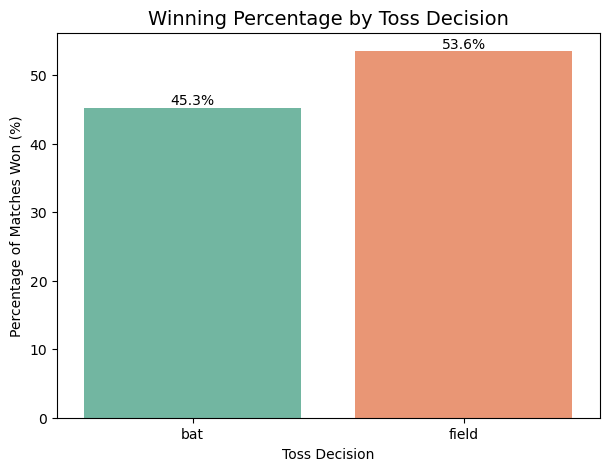

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

ax=sns.barplot(
    data=toss_analysis,
    x='toss_decision',
    y='Win_Percentage',
    hue='toss_decision',
    palette='Set2',
    legend=False
)

plt.title('Winning Percentage by Toss Decision', fontsize=14)
plt.xlabel('Toss Decision')
plt.ylabel('Percentage of Matches Won (%)')

# Show values on bars
ax.bar_label(ax.containers[0], fmt='%.1f%%')
ax.bar_label(ax.containers[1], fmt='%.1f%%')

plt.show()

# Question 6

In [73]:
#  Horizontal Bar Chart of Top 10 Run-Scorers
top_10_batsmen = (
    ipl.groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_10_batsmen

,batter,batsman_runs
0,V Kohli,8014
1,S Dhawan,6769
2,RG Sharma,6630
3,DA Warner,6567
4,SK Raina,5536
5,MS Dhoni,5243
6,AB de Villiers,5181
7,CH Gayle,4997
8,RV Uthappa,4954
9,KD Karthik,4843


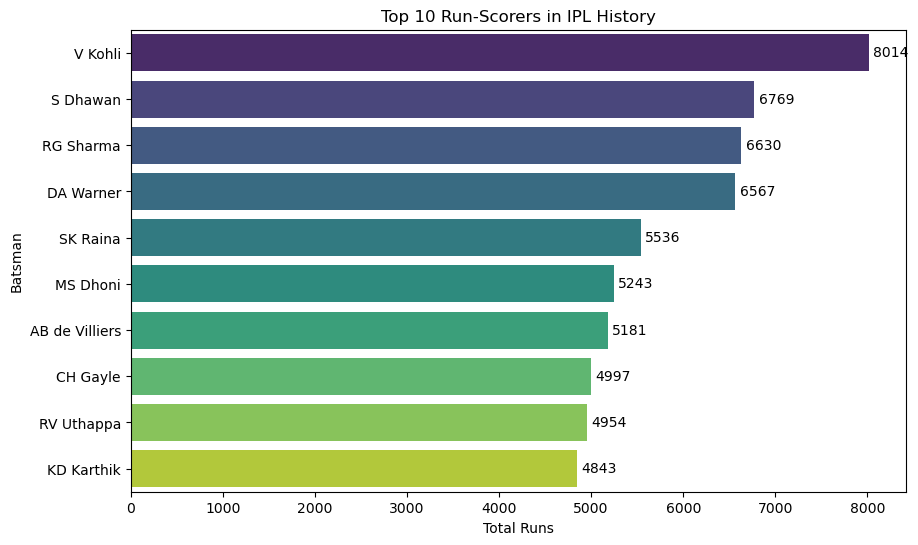

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_10_batsmen,
    x='batsman_runs',
    y='batter',
    hue='batter',
    palette='viridis',
    legend=False
)

plt.title('Top 10 Run-Scorers in IPL History')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')

# Add values
for i, value in enumerate(top_10_batsmen['batsman_runs']):
    plt.text(value+50, i, str(value), va='center')

plt.show()

In [75]:
#Dismissal Patterns of Top 3 Run-Scorers
top3 = top_10_batsmen['batter'].head(3).tolist()

top3

['V Kohli', 'S Dhawan', 'RG Sharma']

In [76]:
dismissals = ipl[
    (ipl['player_dismissed'].isin(top3)) &
    (ipl['dismissal_kind'] != 'not out')
]

dismissals.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,super_over,method,umpire1,umpire2,season_year,is_boundary,over_number,over_phase,year,month
138,335982,2,Royal Challengers Bengaluru,Kolkata Knight Riders,2,2,V Kohli,AB Dinda,W Jaffer,0,...,N,NaN,Asad Rauf,RE Koertzen,2007,non-boundary,3,Powerplay,2008,4
898,335985,2,Royal Challengers Bengaluru,Mumbai Indians,13,4,V Kohli,A Nehra,JH Kallis,0,...,N,NaN,SJ Davis,DJ Harper,2007,non-boundary,14,Middle,2008,4
993,335986,1,Deccan Chargers,Kolkata Knight Riders,8,4,RG Sharma,M Kartik,A Symonds,0,...,N,NaN,BF Bowden,K Hariharan,2007,non-boundary,9,Middle,2008,4
1531,335988,1,Deccan Chargers,Delhi Capitals,18,4,RG Sharma,R Bhatia,AS Yadav,0,...,N,NaN,IL Howell,AM Saheba,2007,non-boundary,19,Death,2008,4
1989,335990,1,Deccan Chargers,Rajasthan Royals,17,6,RG Sharma,SK Warne,A Symonds,0,...,N,NaN,Asad Rauf,MR Benson,2007,non-boundary,18,Death,2008,4


In [77]:
dismissal_counts = (
    dismissals
    .groupby(['player_dismissed','dismissal_kind'])
    .size()
    .reset_index(name='Count')
)

dismissal_counts.head()

,player_dismissed,dismissal_kind,Count
0,RG Sharma,bowled,27
1,RG Sharma,caught,157
2,RG Sharma,caught and bowled,10
3,RG Sharma,lbw,15
4,RG Sharma,run out,11


In [78]:
dismissal_pivot = dismissal_counts.pivot(
    index='player_dismissed',
    columns='dismissal_kind',
    values='Count'
).fillna(0)

dismissal_pivot

dismissal_kind,bowled,caught,caught and bowled,lbw,retired hurt,run out,stumped
player_dismissed,,,,,,,
RG Sharma,27.0,157.0,10.0,15.0,0.0,11.0,3.0
S Dhawan,40.0,112.0,3.0,13.0,1.0,16.0,8.0
V Kohli,39.0,138.0,4.0,12.0,0.0,9.0,5.0


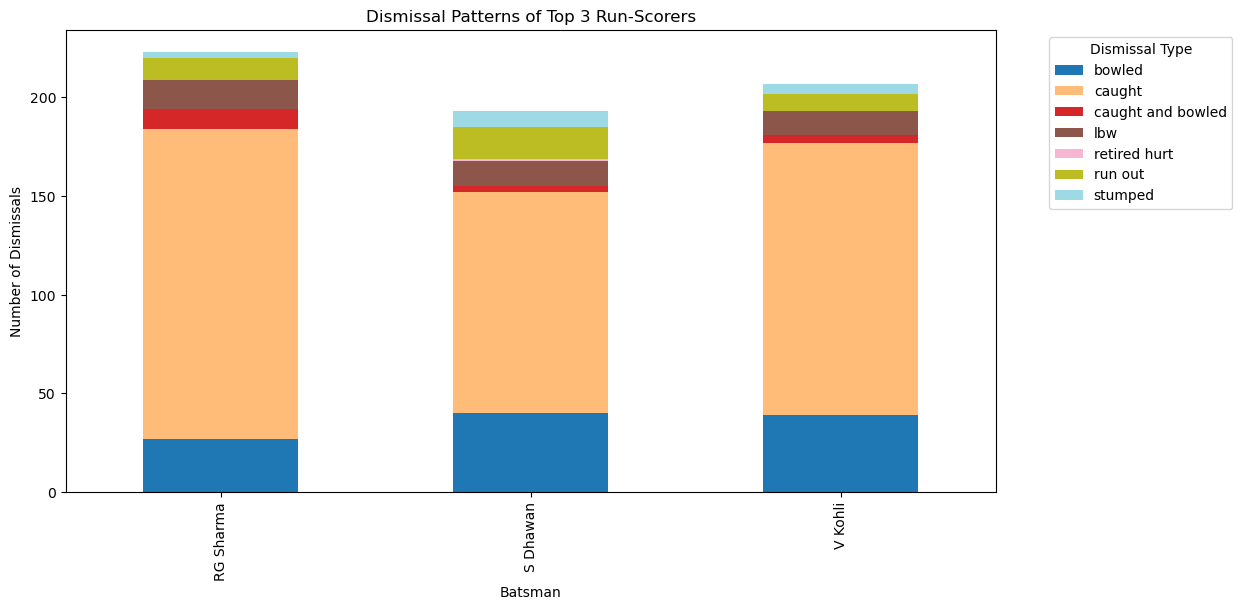

In [79]:
dismissal_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='tab20'
)

plt.title('Dismissal Patterns of Top 3 Run-Scorers')
plt.xlabel('Batsman')
plt.ylabel('Number of Dismissals')

plt.legend(
    title='Dismissal Type',
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)

plt.show()

## Dismissal Patterns of Top Run-Scorers

The stacked bar chart shows how the top three batsmen have been dismissed throughout their IPL careers.

Caught dismissals constitute the majority of wickets for all three players, suggesting that aggressive stroke play often leads to catches. Bowled and LBW dismissals occur less frequently, indicating relatively strong defensive techniques and shot selection.

Overall, these batsmen appear more vulnerable to aerial catches rather than technical weaknesses against the ball.

# Question 7: Seasonal Batting Trends

In [80]:
#Average Runs Per Match by Season
season_runs = (
    ipl.groupby('season')['total_runs']
    .sum()
    .reset_index(name='Total_Runs')
)

In [81]:
#Calculate Total Matches Per Season
season_matches = (
    matches.groupby('season')['id']
    .nunique()
    .reset_index(name='Matches')
)

In [82]:
#Compute Average Runs Per Match
season_avg = season_runs.merge(
    season_matches,
    on='season'
)

season_avg['Avg_Runs_Per_Match'] = (
    season_avg['Total_Runs'] /
    season_avg['Matches']
)

season_avg

,season,Total_Runs,Matches,Avg_Runs_Per_Match
0,2007/08,17937,58,309.258621
1,2009,16353,57,286.894737
2,2009/10,18883,60,314.716667
3,2011,21154,73,289.780822
4,2012,22453,74,303.418919
5,2013,22602,76,297.394737
6,2014,18931,60,315.516667
7,2015,18353,59,311.067797
8,2016,18862,60,314.366667
9,2017,18786,59,318.406780


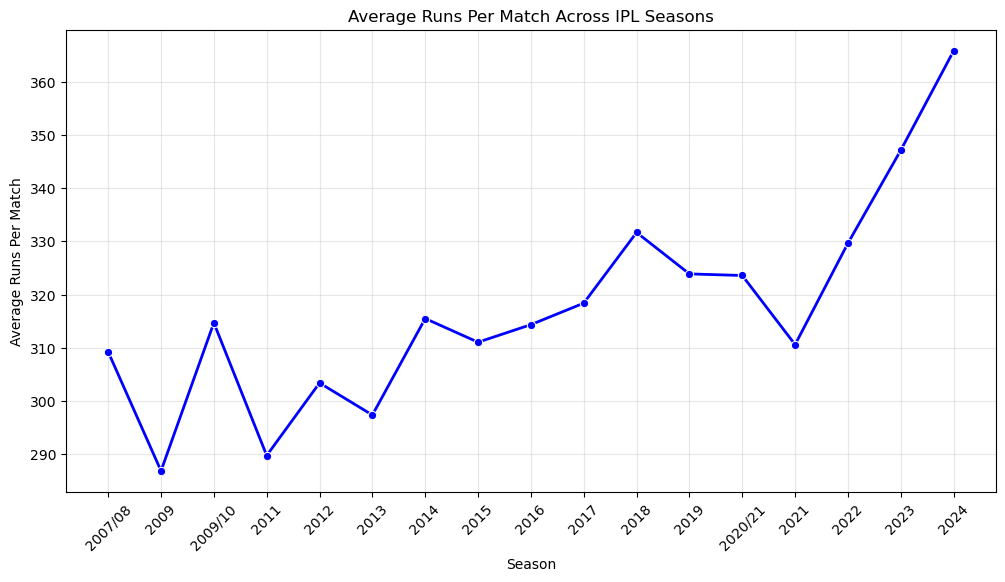

In [83]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=season_avg,
    x='season',
    y='Avg_Runs_Per_Match',
    marker='o',
    linewidth=2,
    color='blue'
)

plt.title('Average Runs Per Match Across IPL Seasons')
plt.xlabel('Season')
plt.ylabel('Average Runs Per Match')
plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

## Seasonal Batting Trends

The line chart illustrates the average runs scored per match in each IPL season.

Several fluctuations are visible across seasons, with noticeable increases in recent years. These spikes indicate a shift toward more aggressive batting strategies and favorable conditions for scoring.

In [84]:
#To perform regression, create a numeric season variable.
season_avg['Year'] = (
    season_avg['season']
    .astype(str)
    .str[:4]
    .astype(int)
)

season_avg.head()

,season,Total_Runs,Matches,Avg_Runs_Per_Match,Year
0,2007/08,17937,58,309.258621,2007
1,2009,16353,57,286.894737,2009
2,2009/10,18883,60,314.716667,2009
3,2011,21154,73,289.780822,2011
4,2012,22453,74,303.418919,2012


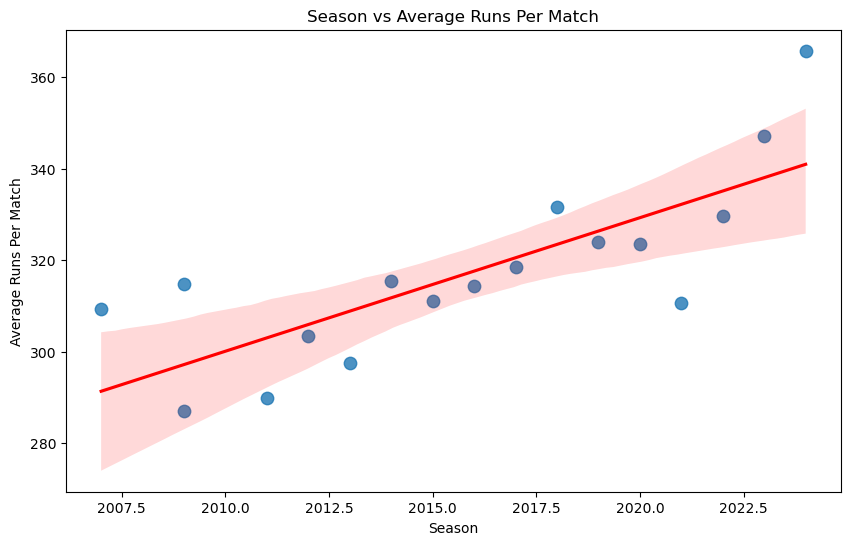

In [85]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=season_avg,
    x='Year',
    y='Avg_Runs_Per_Match',
    scatter_kws={'s':80},
    line_kws={'color':'red'}
)

plt.title('Season vs Average Runs Per Match')
plt.xlabel('Season')
plt.ylabel('Average Runs Per Match')

plt.show()

## Observations

- Average runs per match have generally increased over the years.
- Some seasons exhibit temporary dips due to changes in playing conditions and venues.
- Recent seasons show significantly higher scoring rates.
- The positive regression line indicates a long-term upward trend in batting performance.

# Question 8


In [86]:
top_venues = (
    matches['venue']
    .value_counts()
    .head(5)
)

top_venues

venue
Wankhede Stadium          118
M Chinnaswamy Stadium      94
Eden Gardens               93
Arun Jaitley Stadium       90
MA Chidambaram Stadium     85
Name: count, dtype: int64

In [87]:
top_venues = top_venues.index.tolist()

top_venues

['Wankhede Stadium',
 'M Chinnaswamy Stadium',
 'Eden Gardens',
 'Arun Jaitley Stadium',
 'MA Chidambaram Stadium']

In [88]:
venue_matches = matches[
    matches['venue'].isin(top_venues)
]

venue_matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,season_year,toss_win_match_win
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,...,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,2007,0
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Arun Jaitley Stadium,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,...,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,2007,0
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,...,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper,2007,0
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,...,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan,2007,0
7,335989,2007/08,Chennai,2008-04-23,League,ML Hayden,MA Chidambaram Stadium,Chennai Super Kings,Mumbai Indians,Mumbai Indians,...,runs,6.0,209.0,20.0,N,NaN,DJ Harper,GA Pratapkumar,2007,0


In [89]:
venue_wins = (
    venue_matches.groupby(['venue','winner'])
    .size()
    .reset_index(name='Wins')
)

venue_pivot = venue_wins.pivot(
    index='winner',
    columns='venue',
    values='Wins'
).fillna(0)

venue_pivot

venue,Arun Jaitley Stadium,Eden Gardens,M Chinnaswamy Stadium,MA Chidambaram Stadium,Wankhede Stadium
winner,,,,,
Chennai Super Kings,8.0,6.0,6.0,50.0,13.0
Deccan Chargers,2.0,0.0,1.0,2.0,1.0
Delhi Capitals,37.0,2.0,4.0,4.0,6.0
Gujarat Lions,1.0,2.0,1.0,0.0,1.0
Gujarat Titans,1.0,2.0,1.0,0.0,3.0
Kochi Tuskers Kerala,1.0,1.0,0.0,0.0,1.0
Kolkata Knight Riders,5.0,52.0,10.0,5.0,5.0
Lucknow Super Giants,0.0,1.0,2.0,1.0,3.0
Mumbai Indians,7.0,10.0,9.0,8.0,52.0


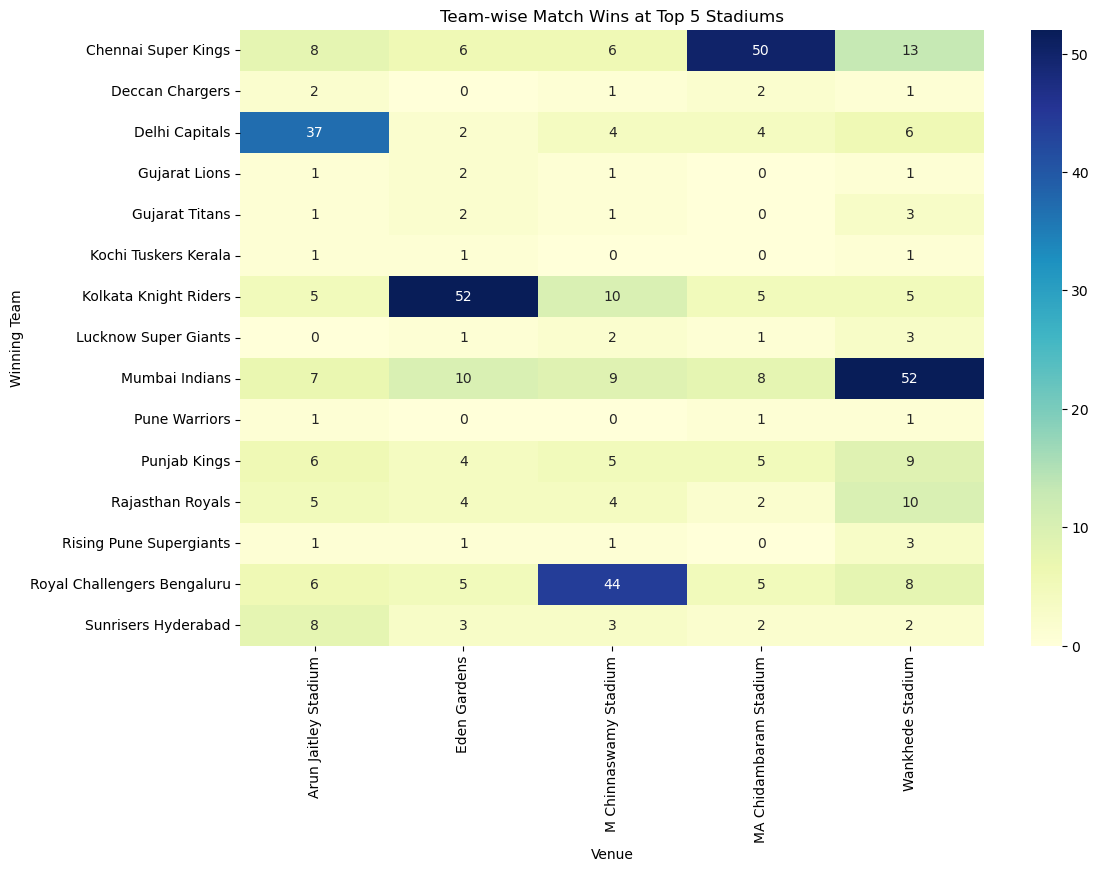

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    venue_pivot,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title('Team-wise Match Wins at Top 5 Stadiums')
plt.xlabel('Venue')
plt.ylabel('Winning Team')

plt.show()

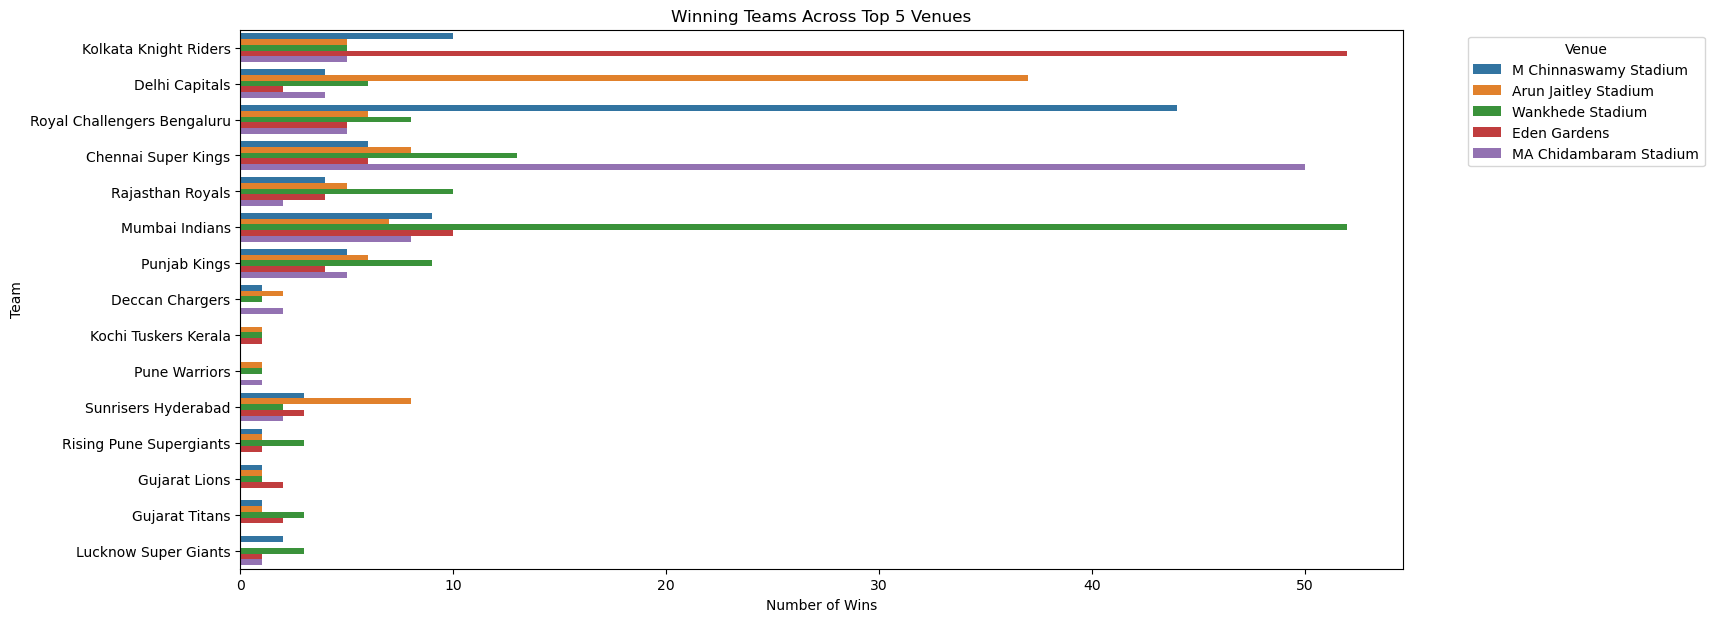

In [91]:
plt.figure(figsize=(15,7))

sns.countplot(
    data=venue_matches,
    y='winner',
    hue='venue'
)

plt.title('Winning Teams Across Top 5 Venues')
plt.xlabel('Number of Wins')
plt.ylabel('Team')

plt.legend(
    title='Venue',
    bbox_to_anchor=(1.05,1)
)

plt.show()

In [92]:
home_advantage = (
    venue_wins.loc[
        venue_wins.groupby('venue')['Wins'].idxmax()
    ]
)

home_advantage.sort_values(
    by='Wins',
    ascending=False
)

,venue,winner,Wins
19,Eden Gardens,Kolkata Knight Riders,52
59,Wankhede Stadium,Mumbai Indians,52
40,MA Chidambaram Stadium,Chennai Super Kings,50
38,M Chinnaswamy Stadium,Royal Challengers Bengaluru,44
2,Arun Jaitley Stadium,Delhi Capitals,37


## Home Advantage Analysis

The analysis reveals that certain franchises enjoy a significant advantage at their home venues.

Mumbai Indians dominate at Wankhede Stadium, Chennai Super Kings perform exceptionally well at MA Chidambaram Stadium, and Kolkata Knight Riders record a large number of victories at Eden Gardens. These patterns suggest that familiarity with playing conditions and crowd support contribute to home advantage.

Among all venues, Wankhede Stadium and MA Chidambaram Stadium exhibit some of the strongest home advantages, with their respective teams recording the highest number of victories.

# Question 9

In [93]:
death_overs = ipl[
    (ipl['over_number'] >= 16) &
    (ipl['over_number'] <= 20)
]

death_overs.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,super_over,method,umpire1,umpire2,season_year,is_boundary,over_number,over_phase,year,month
94,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,15,1,DJ Hussey,AA Noffke,BB McCullum,0,...,N,NaN,Asad Rauf,RE Koertzen,2007,non-boundary,16,Death,2008,4
95,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,15,2,DJ Hussey,AA Noffke,BB McCullum,1,...,N,NaN,Asad Rauf,RE Koertzen,2007,non-boundary,16,Death,2008,4
96,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,15,3,BB McCullum,AA Noffke,DJ Hussey,2,...,N,NaN,Asad Rauf,RE Koertzen,2007,non-boundary,16,Death,2008,4
97,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,15,4,BB McCullum,AA Noffke,DJ Hussey,0,...,N,NaN,Asad Rauf,RE Koertzen,2007,non-boundary,16,Death,2008,4
98,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,15,5,BB McCullum,AA Noffke,DJ Hussey,1,...,N,NaN,Asad Rauf,RE Koertzen,2007,non-boundary,16,Death,2008,4


In [94]:
top_6_teams = (
    death_overs.groupby('batting_team')['total_runs']
    .sum()
    .sort_values(ascending=False)
    .head(6)
)

top_6_teams

batting_team
Mumbai Indians                 11889
Royal Challengers Bengaluru    11330
Chennai Super Kings            11094
Punjab Kings                   10475
Delhi Capitals                 10179
Kolkata Knight Riders          10123
Name: total_runs, dtype: int64

In [95]:
top_6_teams = top_6_teams.index.tolist()

top_6_teams

['Mumbai Indians',
 'Royal Challengers Bengaluru',
 'Chennai Super Kings',
 'Punjab Kings',
 'Delhi Capitals',
 'Kolkata Knight Riders']

In [96]:
death_over_runs = (
    death_overs.groupby(
        ['match_id',
         'inning',
         'batting_team',
         'over_number']
    )['total_runs']
    .sum()
    .reset_index()
)

death_over_runs.head()

,match_id,inning,batting_team,over_number,total_runs
0,335982,1,Kolkata Knight Riders,16,4
1,335982,1,Kolkata Knight Riders,17,14
2,335982,1,Kolkata Knight Riders,18,7
3,335982,1,Kolkata Knight Riders,19,21
4,335982,1,Kolkata Knight Riders,20,22


In [97]:
death_over_runs = death_over_runs[
    death_over_runs['batting_team'].isin(top_6_teams)
]

death_over_runs.head()

,match_id,inning,batting_team,over_number,total_runs
0,335982,1,Kolkata Knight Riders,16,4
1,335982,1,Kolkata Knight Riders,17,14
2,335982,1,Kolkata Knight Riders,18,7
3,335982,1,Kolkata Knight Riders,19,21
4,335982,1,Kolkata Knight Riders,20,22


C:\Users\Dilawar Singh\AppData\Local\Temp\ipykernel_22636\2006227315.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


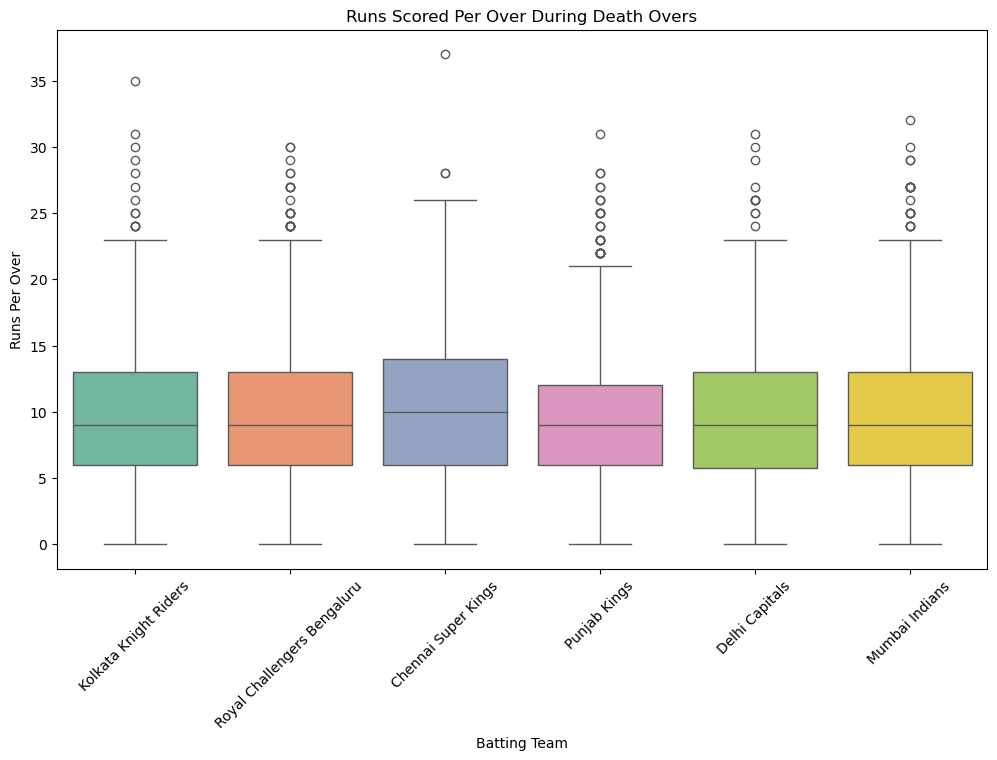

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,7))

sns.boxplot(
    data=death_over_runs,
    x='batting_team',
    y='total_runs',
    palette='Set2'
)

plt.title('Runs Scored Per Over During Death Overs')
plt.xlabel('Batting Team')
plt.ylabel('Runs Per Over')

plt.xticks(rotation=45)

plt.show()

## Death Over Performance Analysis

The box plot illustrates the distribution of runs scored per over during the death overs (16–20) for the six teams with the highest aggregate death-over runs.

Teams with higher median values consistently score more runs in the final overs, reflecting strong finishing capabilities. Wider distributions and numerous outliers indicate occasional explosive overs where teams score exceptionally high runs.

In [99]:
death_over_runs.groupby('batting_team')['total_runs']\
.mean()\
.sort_values(ascending=False)

batting_team
Royal Challengers Bengaluru    10.253394
Chennai Super Kings            10.196691
Mumbai Indians                 10.109694
Kolkata Knight Riders           9.577105
Punjab Kings                    9.514078
Delhi Capitals                  9.355699
Name: total_runs, dtype: float64

## Conclusion

Death overs play a crucial role in determining match outcomes. The box plot reveals that certain teams consistently outperform others in overs 16–20, highlighting the importance of power hitters and finishing specialists in modern T20 cricket.

In [100]:
death_stats = (
    death_over_runs.groupby('batting_team')['total_runs']
    .agg(
        Mean='mean',
        Median='median',
        Std_Dev='std',
        Variance='var'
    )
    .sort_values(by='Median', ascending=False)
)

death_stats

,Mean,Median,Std_Dev,Variance
batting_team,,,,
Chennai Super Kings,10.196691,10.0,5.141772,26.437818
Delhi Capitals,9.355699,9.0,5.169914,26.728008
Kolkata Knight Riders,9.577105,9.0,5.213797,27.183680
Mumbai Indians,10.109694,9.0,5.447533,29.675617
Punjab Kings,9.514078,9.0,5.131457,26.331847
Royal Challengers Bengaluru,10.253394,9.0,5.488051,30.118705


In [101]:
death_stats.sort_values(
    ['Median', 'Std_Dev'],
    ascending=[False, True]
)

,Mean,Median,Std_Dev,Variance
batting_team,,,,
Chennai Super Kings,10.196691,10.0,5.141772,26.437818
Punjab Kings,9.514078,9.0,5.131457,26.331847
Delhi Capitals,9.355699,9.0,5.169914,26.728008
Kolkata Knight Riders,9.577105,9.0,5.213797,27.183680
Mumbai Indians,10.109694,9.0,5.447533,29.675617
Royal Challengers Bengaluru,10.253394,9.0,5.488051,30.118705


In [ ]:
death_stats.sort_values(
    ['Median', 'Variance'],
    ascending=[False, False]
)

 # Part C – Storytelling & Final Report 

## 1. Executive Summary  – What is the most important insight from your analysis? 


The analysis of IPL match and ball-by-ball data revealed several patterns related to batting trends, team performance, toss decisions, and death-over scoring. One of the most significant findings is that IPL matches have become increasingly high-scoring over the years, indicating a shift toward more aggressive batting strategies. Additionally, certain teams enjoy a strong home advantage at specific venues, while death-over performance plays a crucial role in determining match outcomes.

# 2. Key Insights

### • Top run scorers dominate through consistency rather than explosive innings.
The top ten batsmen have accumulated significantly more runs than other players, demonstrating exceptional longevity and consistency.

### • IPL has become more batting-friendly over time.
The average runs per match have increased across seasons, and the regression trend line shows a positive long-term trend.

### • Toss decisions do not guarantee victory.
Although teams choosing to field first often achieve a slightly higher winning percentage, the advantage is not consistent across all seasons.

### • Home advantage exists at major venues.
Teams such as Mumbai Indians at Wankhede Stadium and Chennai Super Kings at MA Chidambaram Stadium have recorded a large number of wins at their home grounds.

### • Death-over performance is critical.
Teams with strong finishers consistently score higher in overs 16–20, while some teams exhibit explosive but highly variable performances.

### insert graphs

# 3. Recommendation for Team Strategy

Based on the analysis, teams should prioritize building strong death-over batting units. Reliable finishers capable of accelerating scoring in the final overs can significantly influence match outcomes.

Additionally, teams should adapt their strategy according to venue conditions rather than relying solely on toss decisions, since home advantage and familiarity with local pitches play an important role in success.

# 4. Self Reflection

One limitation of the dataset is the absence of contextual information such as pitch conditions, weather, player fitness, team combinations, and player strike rates in different phases of the innings. These factors influence match outcomes but are not captured in the available data.

If additional data were available, analysis could be extended to study player matchups, venue-specific batting and bowling performance, impact of weather conditions, and predictive models for match outcomes.